In [1]:
import sys
sys.path.append(r'/Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/src')
from utils.stock_simulation import *
from utils.market_simulator import *

# Spread Model Comparison — Observations & Conclusions

---

## 1. Simulation Setup

| Parameter | Value |
|---|---|
| Underlying process | GBM, drift = 0, σ = 20% annualized |
| Time step `dt` | 10ms (0.01s) |
| Horizon | 1 trading day |
| Total steps N | ~2,340,000 |
| Vol window | 6000 steps = 60 seconds lookback |
| Alpha | 0.5 (price / annualized vol unit) |

---

## 2. Numerical Results

| Metric | Static | Stochastic | Adaptive | Asymmetric |
|---|---|---|---|---|
| Spread mean | 1.0000 | 1.2002 | 0.9992 | 1.2008 |
| Spread std | 0.0000 | 0.0041 | 0.0093 | 0.0041 |
| Spread min | 1.0000 | 1.1828 | 0.9704 | **1.0000** |
| Spread max | 1.0000 | 1.2230 | 1.0362 | 1.2229 |
| Relative spread | 1.001% | 1.201% | 1.000% | 1.202% |
| Ask/Bid vol (ann.) | ~20% | ~20% | ~20% | ~20% |

---

## 3. Observations

### 3.1 The models are numerically correct
Each model's mean spread is consistent with its formula:
- **Static**: `2 * spread_0 = 2 * 0.5 = 1.0` ✓
- **Stochastic**: `2 * (spread_0 + α * RV) ≈ 2 * (0.5 + 0.5 * 0.2) = 1.2` ✓
- **Adaptive**: `2 * (spread_0 + α * vol_excess) ≈ 2 * 0.5 = 1.0` since `vol_excess ≈ 0` on average ✓
- **Asymmetric**: converges to the same steady-state as stochastic ≈ 1.2 in calm regime, but hits floor 1.0 during the 60s warmup ✓

The asymmetric model's `min = 1.0000` is the S₀ floor enforced during the warmup period — correct behavior.

### 3.2 The differences between models are very small
The stochastic and asymmetric models are statistically near-identical (mean 1.2002 vs 1.2008, std both 0.0041). The entire spread range across the day is only **0.04 price units** wide for both. The adaptive model has slightly more variation (std 0.0093) but its range is also narrow (0.067 price units).

This is not a bug — it is a direct consequence of the underlying process.

### 3.3 Root cause: GBM has constant volatility by construction
All three dynamic spread models are designed to react to **changes in realized volatility**. But GBM generates returns with constant variance `σ² * dt` at every step. There is no volatility clustering, no regime change, no news shock. The rolling realized vol barely deviates from the input 20% — which means the vol-driven component of the spread is essentially constant too.

In other words: **the models are relevant, but GBM is the wrong process to stress-test them**.

### 3.4 Ask/bid vol ≈ 20% for all models
The annualized vol of the ask and bid price series is approximately the same as the underlying mid price vol (~20%) across all four models. This makes sense: the spread around mid is ~1% of the price level, so the *variation* in the spread is orders of magnitude smaller than the price moves. The ask/bid vol is dominated entirely by the mid price process, not by the spread dynamics.

---

## 4. What Would Make the Models Meaningfully Differ

The three dynamic models would show visible, economically significant differentiation under:

| Scenario | Why it matters |
|---|---|
| **Stochastic vol process** (Heston, SABR, rough vol) | Vol itself becomes random → spread reacts to vol regime changes |
| **GARCH residuals** | Volatility clustering → spreads should widen after large moves and stay wide |
| **Intraday U-shaped vol pattern** | Higher vol at open/close → spreads should be wider at open, tighter at midday |
| **Instantaneous vol spike** (e.g. simulated news shock) | The asymmetric model's `κ_u >> κ_d` asymmetry only becomes visible when there is an actual spike to react to |

The **asymmetric model in particular** would show the clearest differentiation under a vol spike: it would widen in ~1-2 steps (half-life ~14ms at κ_u=50, dt=10ms) and then decay back slowly over several seconds (half-life ~350ms at κ_d=2). Under constant GBM vol, that dynamic never triggers.

---

## 5. Conclusions

1. **The implementation is correct.** All models produce internally consistent numbers that match their theoretical formulas. The sanity check confirms the GBM simulation itself is well-calibrated (realized vol = 20.03% vs input 20%).

2. **The models are theoretically sound but empirically indistinguishable under GBM.** This is expected — the models are motivated by empirical microstructure evidence on real order books where vol is stochastic and clustered, not by stylized GBM paths.

3. **The adaptive model has the largest spread std (0.0093)** despite centering on vol-excess. This is because the relative spread_0 is price-adaptive (full array), which introduces mild price-level variation even when vol is flat.

4. **The asymmetric model adds the most theoretical realism** (spread stickiness, asymmetric reversion, hard floor) but requires a vol regime change to show its behavior. Its value is not visible in this simulation.

5. **Next step to validate the dynamic models**: replace the GBM with a Heston or GARCH(1,1) process, or manually inject a vol spike at a specific time step, and observe how the three dynamic models respond differently in the width panel and in the `corr(width, RV)` metric.

---

*Simulation: 1 trading day, dt=10ms, σ=20%, drift=0 — Market Making Project M2*


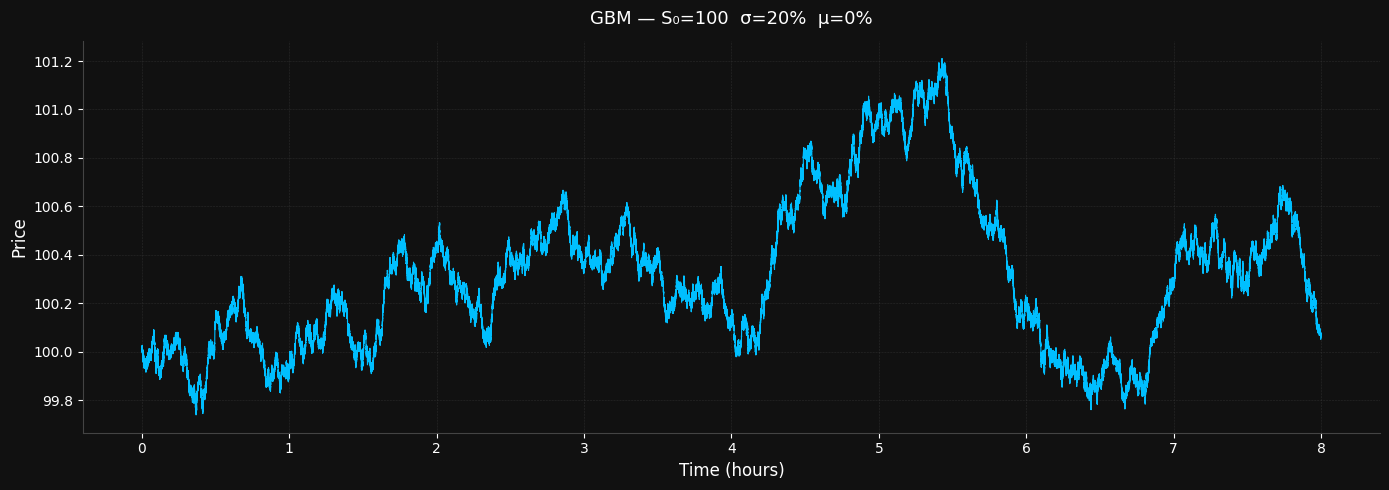

In [11]:
drift = 0
vol = 0.2
stock_try = Stock(drift, vol)
stock_try.simulate_gbm(n_days=1, dt_seconds=0.01)
stock_try.plot_path()


──────────────────────────────────────────────────────────────
  Sanity check — GBM
──────────────────────────────────────────────────────────────
Metric                                     Value      Expected
──────────────────────────────────────────────────────────────
Realized ann. vol                      20.0247%     20.0000%
Realized ann. drift (Itô)                 0.1776       -0.0200
Skewness of log-returns                  -0.0016            ~0
Excess kurtosis                           0.0057            ~0
Min price                                99.7389             —
Max price                               101.2105             —
Final price                             100.0705             —
──────────────────────────────────────────────────────────────


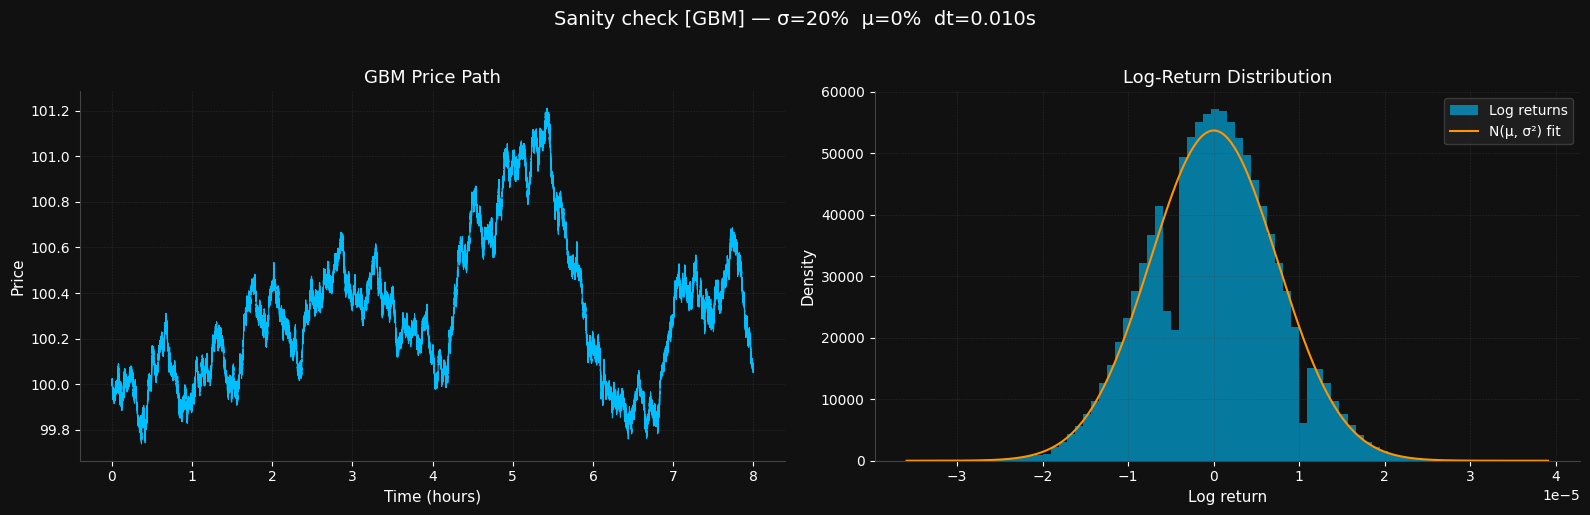

In [12]:
stock_try.sanity_check()

/Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/src/utils/market_simulator/market.py:261: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


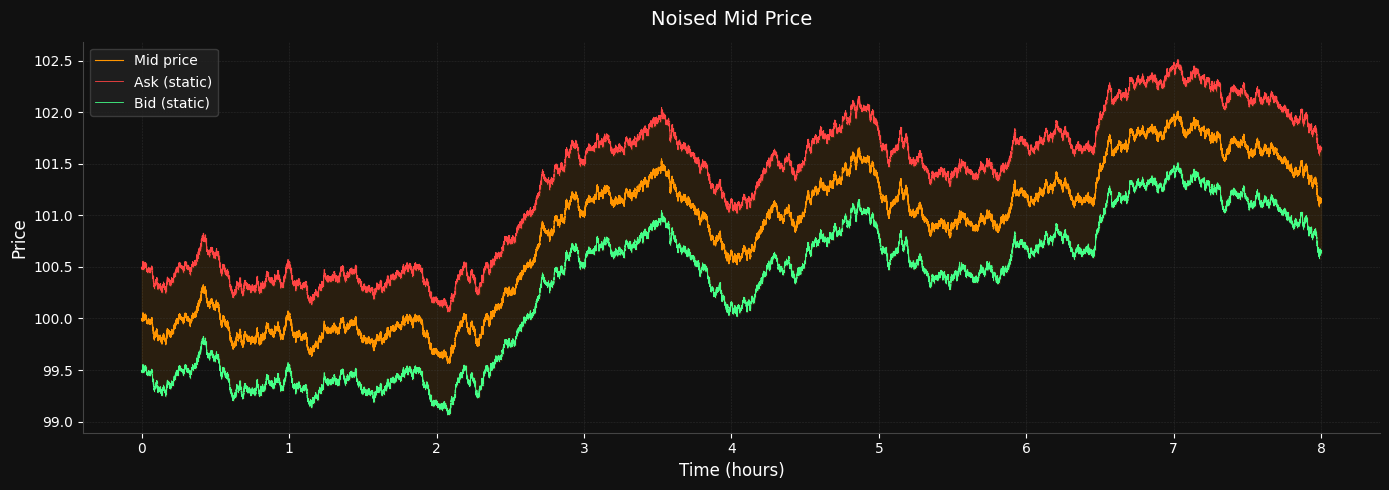

In [4]:
market = Market(stock_try)
market.generate_noised_mid_price()
market.build_spread()
market.plot_noised_mid_price()


Coefficient annualization : 26939.933184772377


/Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/market_making/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


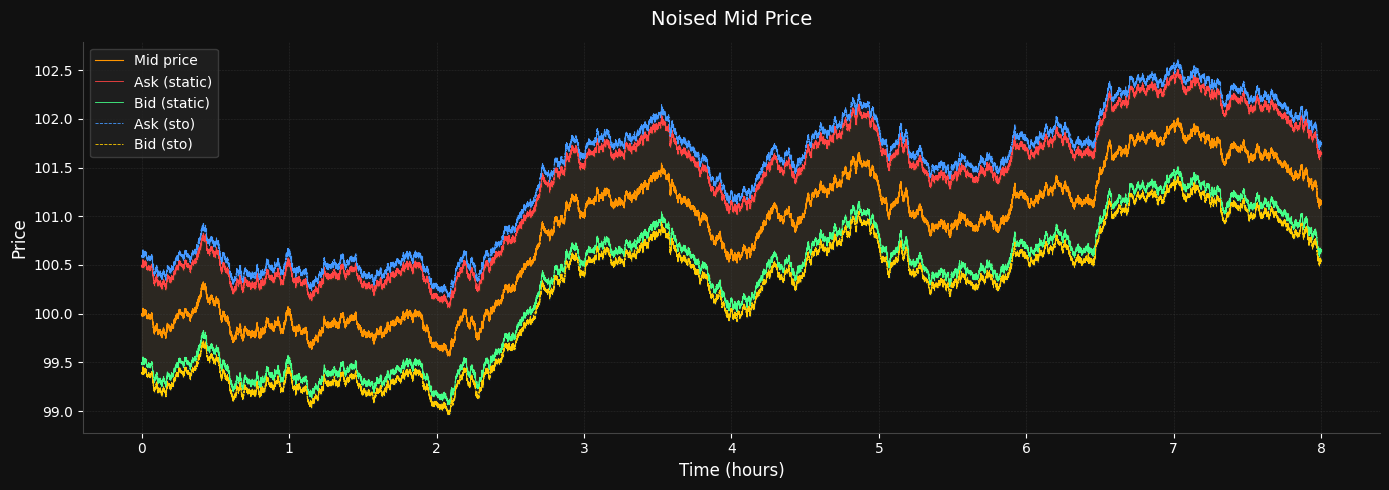

In [5]:
param = {"window_size": 6000, "alpha": 0.5}
market.build_spread(option = "Sto", **param)
market.plot_noised_mid_price()

Coefficient annualization : 26939.933184772377


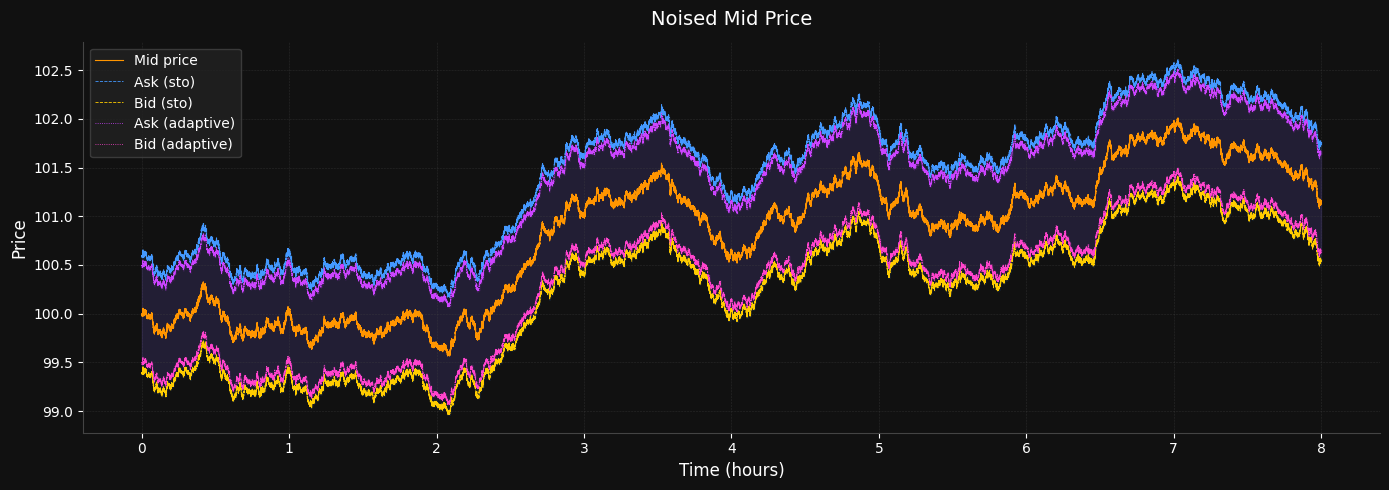

In [6]:
param = {"window_size": 6000, "alpha": 0.5}
market.build_spread(option = "Adaptive", **param)
market.plot_noised_mid_price(["Sto", "Adaptive"])

dt : 0.01 


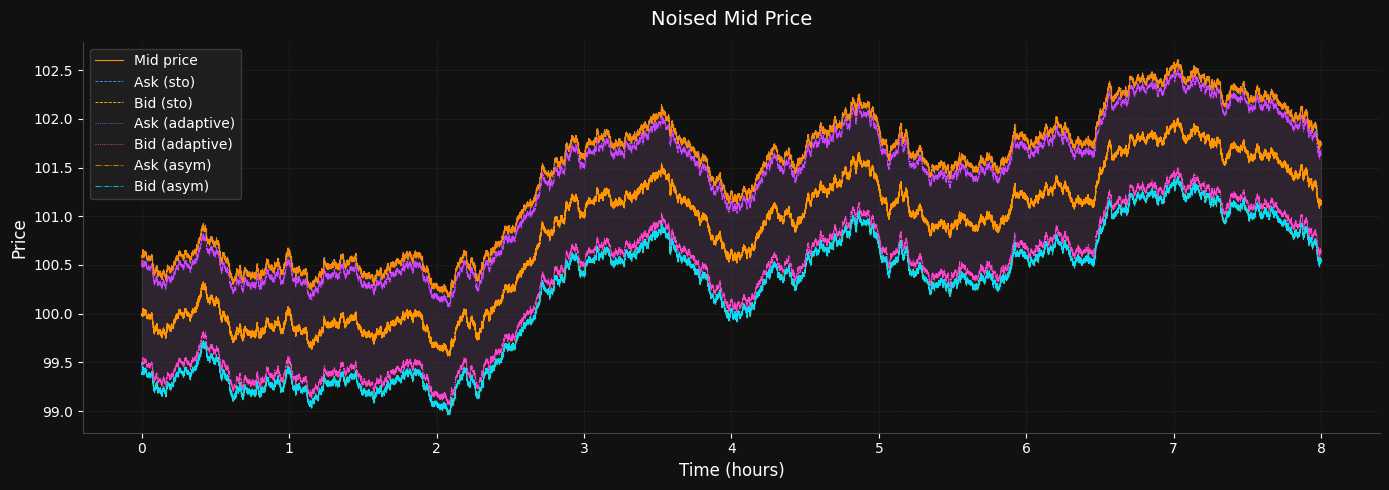

In [7]:
param = {"window_size": 6000, "alpha": 0.5, "tick_factor":100}
market.build_spread(option = "Asym", **param)
market.plot_noised_mid_price(["Sto", "Adaptive", "Asym"])

/Users/edouardblanc/Desktop/cours_203_m2/S2/electronic_trading/projet_market_making/src/utils/market_simulator/market.py:398: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


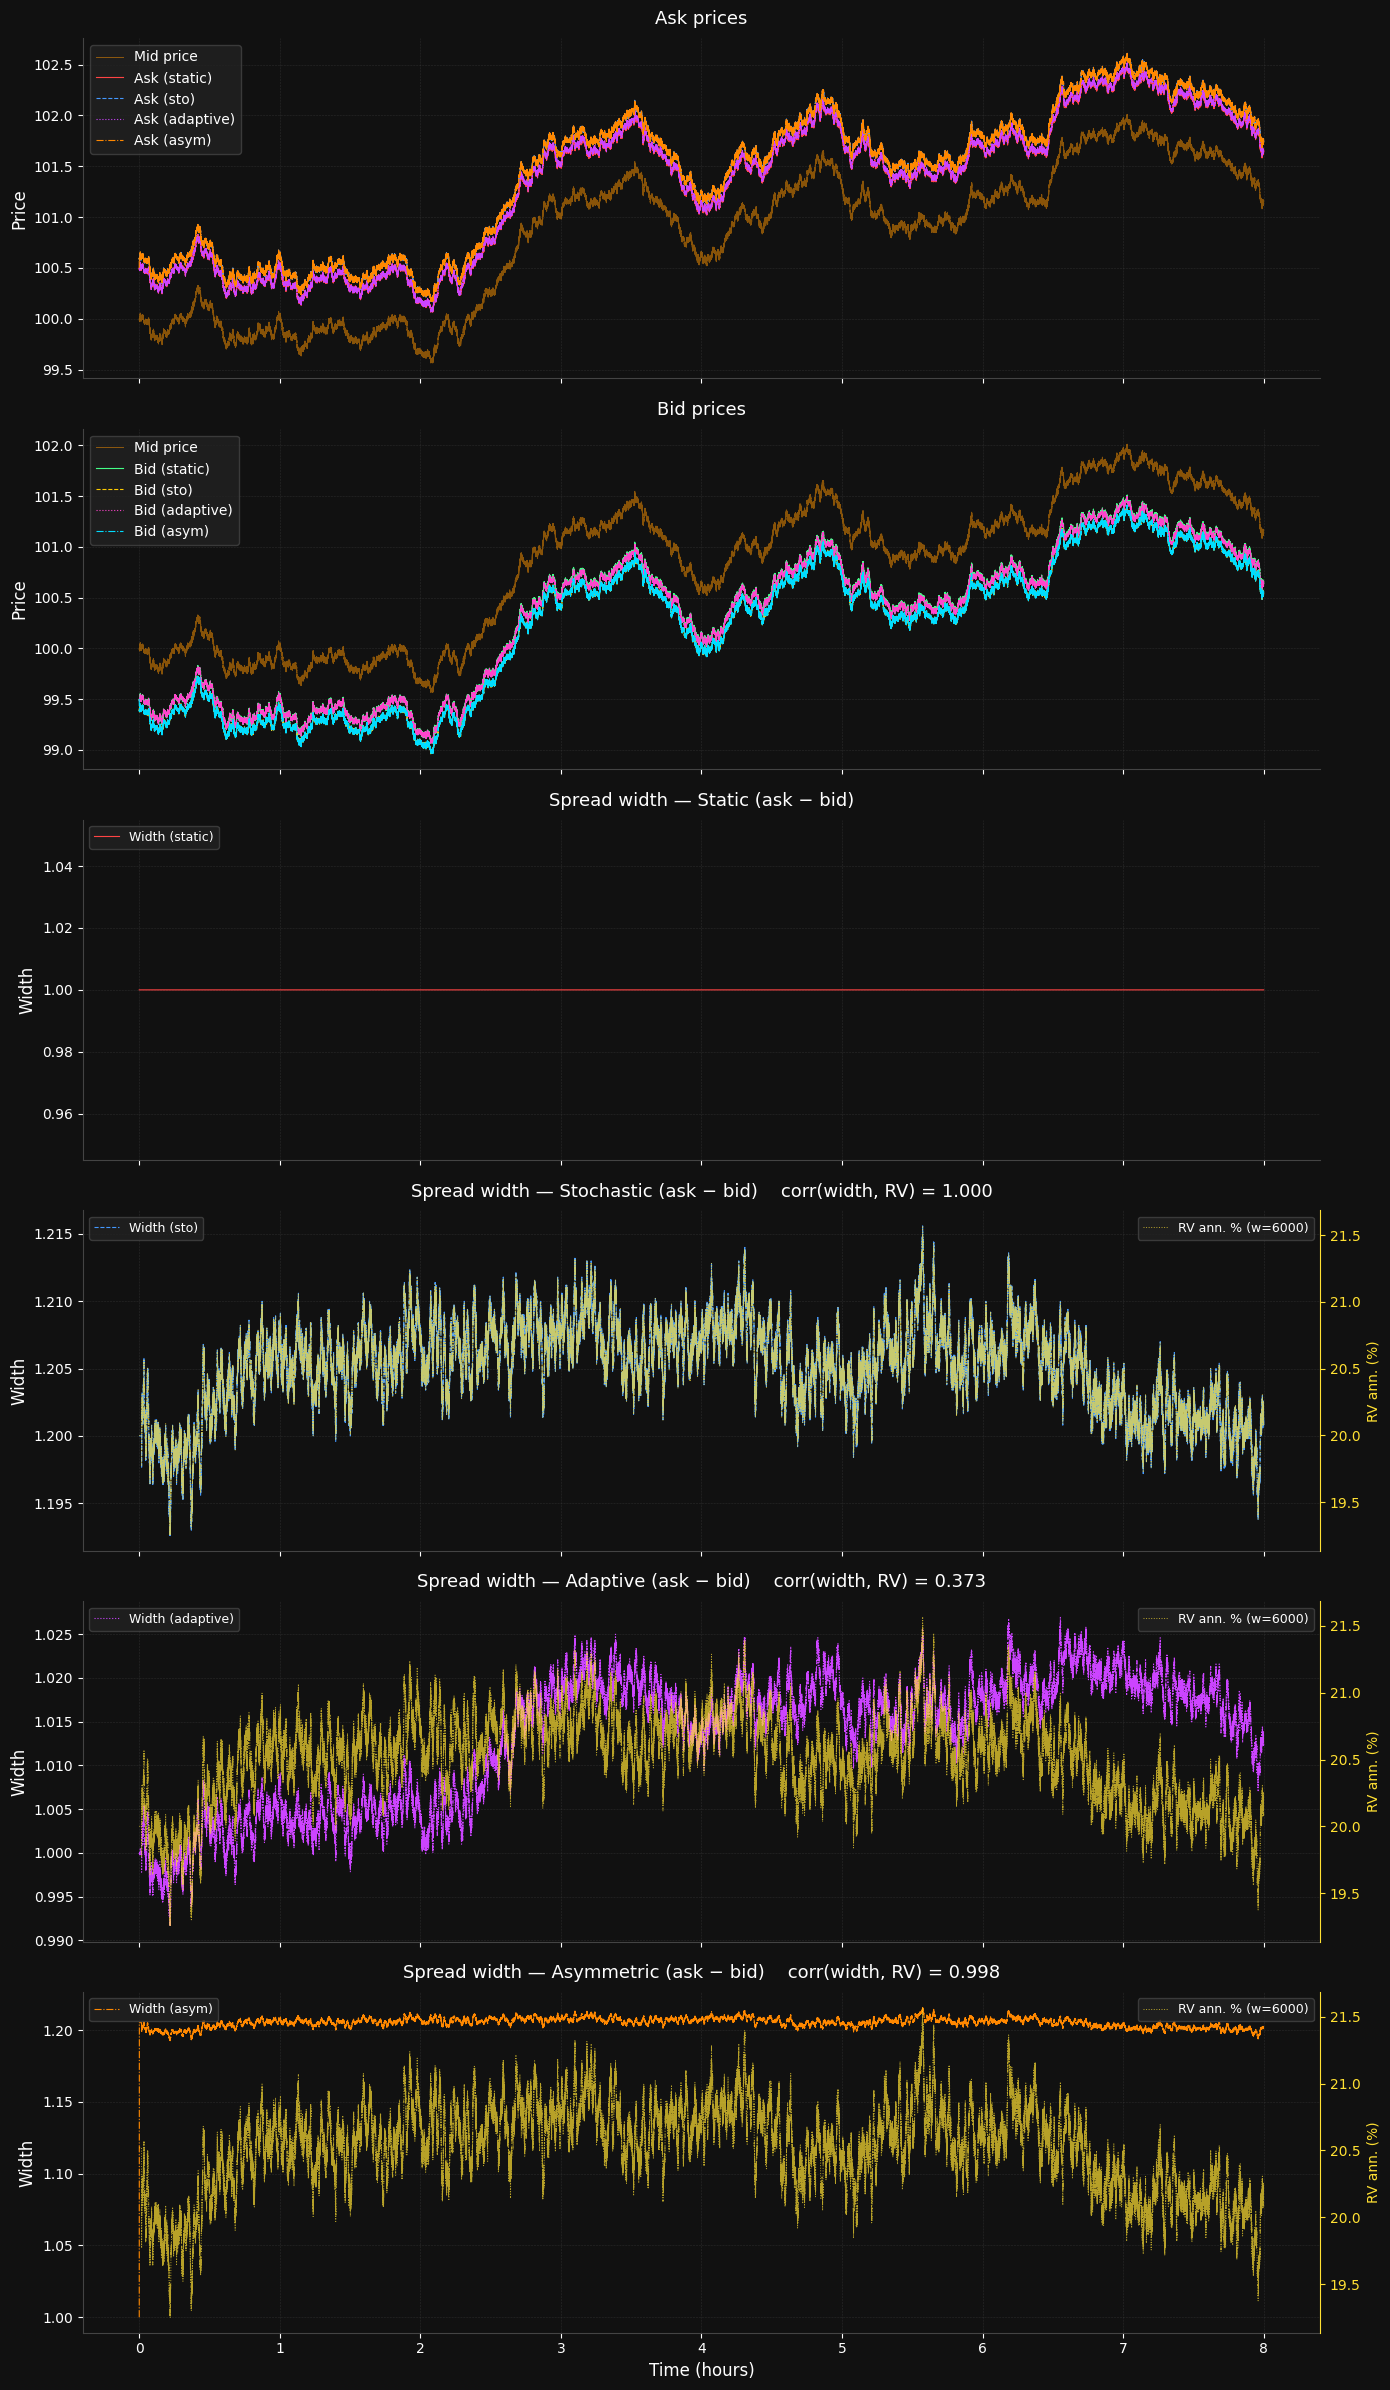

In [8]:
market.compare_spreads()

In [9]:
market.sanity_check_spreads()

────────────────────────────────────────────────────────────────────────────
Metric                                               Static      Stochastic        Adaptive      Asymmetric
────────────────────────────────────────────────────────────────────────────
Spread mean (price units)                            1.0000          1.2052          1.0133          1.2053
Spread std  (price units)                            0.0000          0.0033          0.0074          0.0033
Spread min  (price units)                            1.0000          1.1926          0.9916          1.0000
Spread max  (price units)                            1.0000          1.2156          1.0270          1.2157
Relative spread mean (%)                           0.9920%        1.1955%        1.0051%        1.1956%
Relative spread std  (%)                           0.0068%        0.0090%        0.0032%        0.0090%
Ask bias vs mid (mean)                               0.5000          0.6026          0.5067       

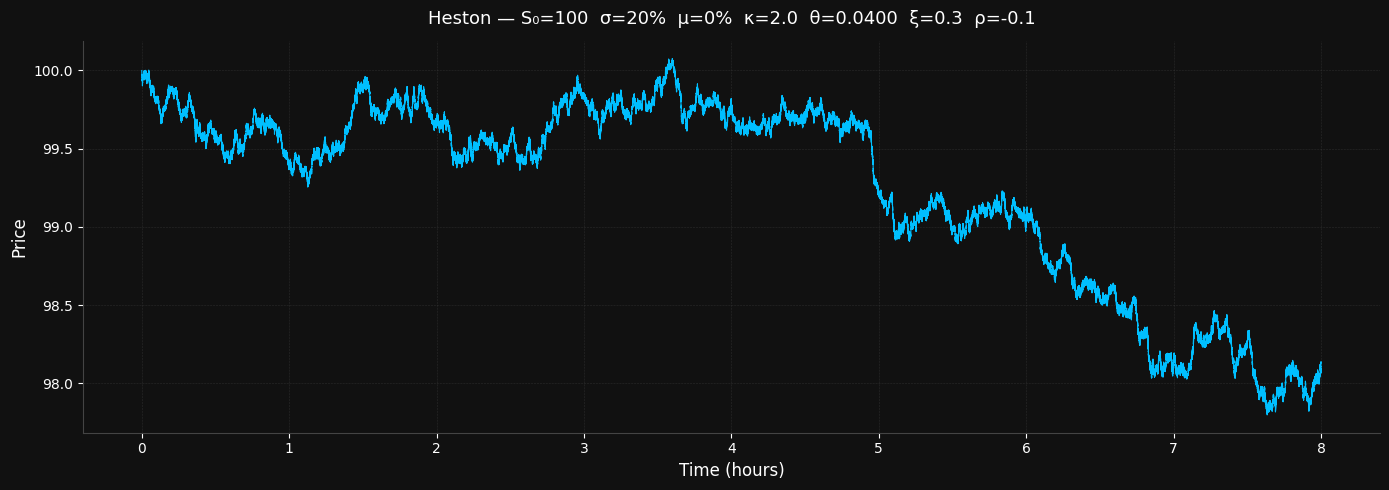

──────────────────────────────────────────────────────────────
  Sanity check — Heston
──────────────────────────────────────────────────────────────
Metric                                     Value      Expected
──────────────────────────────────────────────────────────────
Realized ann. vol                      20.4919%     20.0000%
Realized ann. drift (Itô)                -4.7596       -0.0200
Skewness of log-returns                   0.0005            ~0
Excess kurtosis (60s agg.)                0.2074  >0 (fat tails)
Min price                                97.7973             —
Max price                               100.0768             —
Final price                              98.1290             —
──────────────────────────────────────────────────────────────
Vol of vol realized                      0.3000       0.3000
Autocorr sq. returns (60s agg.)           0.0678   >0 expected
Feller condition (2κθ/ξ²)                 1.7778   >1 required
─────────────────────────────────

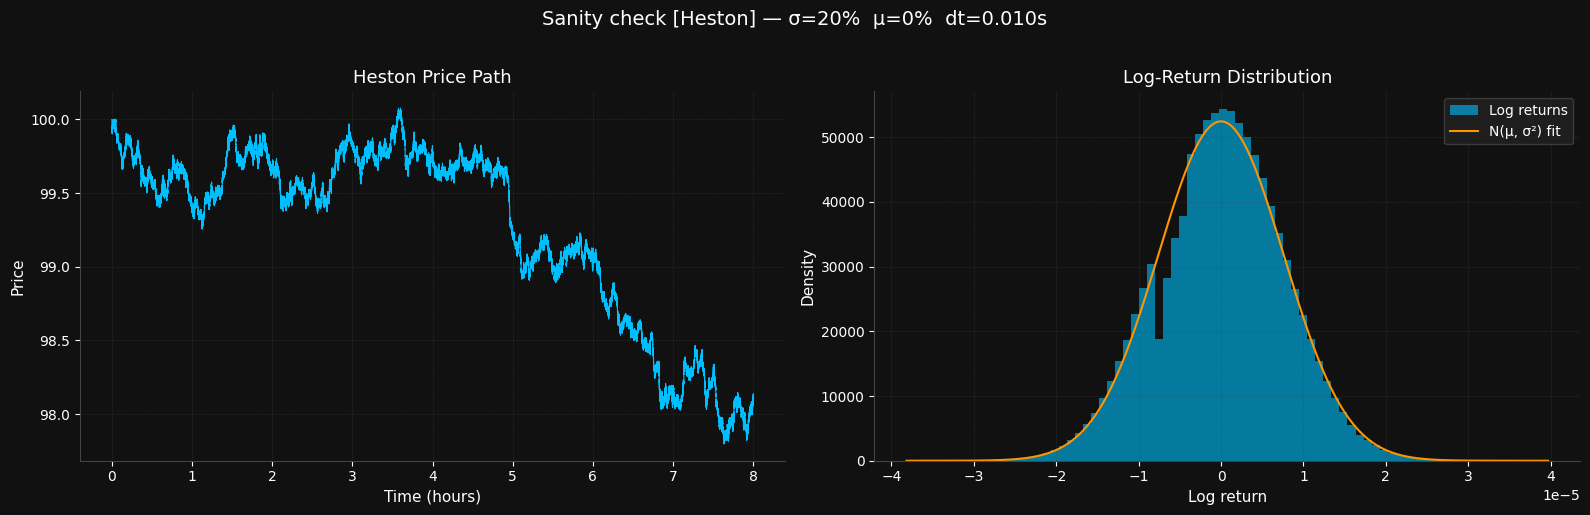

In [13]:
stock_try = Stock(drift=0.0, vol=0.20)                                                                                                                                                                          
stock_try.simulate_heston(n_days=1, dt_seconds=0.01, xi=0.3, rho=-0.1)
stock_try.plot_path() 
stock_try.sanity_check()                                                                                                                                     
   

In [ ]:
market = Market(stock_try)
market.generate_noised_mid_price()
market.build_spread()
market.plot_noised_mid_price()

In [ ]:
param = {"window_size": 6000, "alpha": 0.5}
market.build_spread(option = "Sto", **param)
market.plot_noised_mid_price()

In [ ]:
param = {"window_size": 6000, "alpha": 0.5}
market.build_spread(option = "Adaptive", **param)
market.plot_noised_mid_price(["Sto", "Adaptive"])

In [ ]:
param = {"window_size": 6000, "alpha": 0.5, "tick_factor":100}
market.build_spread(option = "Asym", **param)
market.plot_noised_mid_price(["Sto", "Adaptive", "Asym"])

In [ ]:
market.compare_spreads()

In [ ]:
market.sanity_check_spreads()

# Heston vs GBM — Does Stochastic Vol Help the Spread Models?

---

## Numerical Results

| Metric | GBM | Heston (ξ=0.3, κ=2) |
|---|---|---|
| Realized vol | ~20.0% | ~20.3% |
| **Vol path range** | **constant** | **19.97% → 20.99%** |
| Excess kurtosis (60s agg.) | ~0 | 0.41 |
| Autocorr of sq. returns (60s) | ~0 | 0.016 |
| Feller condition (2κθ/ξ²) | — | 1.78 |

| Spread model | GBM std | Heston std |
|---|---|---|
| Static | 0.0000 | 0.0000 |
| Stochastic | 0.0033 | 0.0027 |
| Adaptive | 0.0074 | 0.0083 |
| Asymmetric | 0.0033 | 0.0027 |

---

## Conclusion: Heston with Standard FX Parameters Does Not Help

**The three dynamic spread models remain essentially indistinguishable under Heston (ξ=0.3, κ=2), just as they were under GBM.**

The root cause is a time-scale mismatch. In the Heston model all parameters are expressed in annualized units. With `dt = 0.01s`, the per-step time fraction is `dt/T_year ≈ 1.38 × 10⁻⁹ years`. The CIR variance process only moves by:

```
Δv ~ ξ · √v · √(dt_year) ≈ 0.3 × 0.2 × 3.7×10⁻⁵ ≈ 2.2×10⁻⁶  per step
```

Accumulated over a full trading day (N ≈ 2.34 M steps), the total diffusion in variance is:

```
√N × 2.2×10⁻⁶ ≈ 0.003
```

which moves vol from 20% to at most ~21% — a 1 percentage-point range. **The spread models cannot see a 1 pp vol swing.** The spread std numbers are nearly identical between GBM and Heston.

The mild kurtosis (0.41) and near-zero autocorrelation (0.016) confirm that at 10ms resolution, one day of Heston is still close to Gaussian — the fat tails require returning aggregation to ~minutes to become visible.

---

## What Would Actually Differentiate the Models

Standard Heston parameters (calibrated to the options smile) describe **slow, weekly-scale** vol dynamics. To stress-test the spread models intraday, the right approach is **not** a different continuous-time process — it is a **simulated vol shock**:

| Approach | How | Why it works |
|---|---|---|
| Manual vol spike | Set `stock.simulation[t₀:]` to a path re-simulated at 2×σ for 30 min, then revert | Sudden regime shift that all dynamic models must react to — the asymmetric model's κ_u >> κ_d asymmetry becomes directly visible |
| GARCH(1,1) residuals | Replace GBM Z draws with GARCH innovations | Produces vol clustering at the intraday step level |
| Intraday U-shape | Multiply σ by a deterministic U-shape curve (high at open/close) | Realistic, easy, guaranteed spread divergence |

The **asymmetric model** in particular is designed for shock response. Its value only becomes visible when there is an actual jump in realized vol to react to — `κ_u=50` means a half-life of ~14ms on the way up, `κ_d=2` means a half-life of ~350ms on the way down. Under flat vol, that asymmetry never triggers.

---

*Heston is theoretically correct and produces fat tails at daily+ aggregation, but is the wrong tool for intraday spread differentiation at dt=10ms.*


# Vol Shock Experiment — Making the Spread Models Visibly Differ

In [ ]:
# GBM base path + vol shock at 40% of the day, lasting 5 minutes, vol ×3
stock_shock = Stock(drift=0.0, vol=0.20)
stock_shock.simulate_gbm(n_days=1, dt_seconds=0.01)
stock_shock.inject_vol_shock(t_start_frac=0.4, duration_s=300, shock_factor=3.0)
stock_shock.plot_path()


In [ ]:
# Build all spread models — use window_size=1200 (12s) so spreads react quickly to the shock
market_shock = Market(stock_shock)
market_shock.generate_noised_mid_price()
market_shock.build_spread()
market_shock.build_spread(option="Sto",      window_size=1200, alpha=0.5)
market_shock.build_spread(option="Adaptive", window_size=1200, alpha=0.5)
market_shock.build_spread(option="Asym",     window_size=1200, alpha=0.5, tick_factor=100)


In [ ]:
market_shock.compare_spreads()


In [ ]:
market_shock.sanity_check_spreads()
